In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
def random_weights_generator(input_n,hidden_n,hidden_layers,output_n):
    total_layers=2+hidden_layers
    global_weights_arr=[]
    global_bias_arr=[]
    for i in range(total_layers-1):
        if i==0:
            global_weights_arr.append(np.random.uniform(-0.04,0.04,(input_n,hidden_n)))
            global_bias_arr.append(np.zeros(hidden_n))
        elif i==total_layers-2:
            global_weights_arr.append(np.random.uniform(-0.04,0.04,(hidden_n,output_n)))
            global_bias_arr.append(np.zeros(output_n))
        else:
            global_weights_arr.append(np.random.uniform(-0.04,0.04,(hidden_n,hidden_n)))
            global_bias_arr.append(np.zeros(hidden_n))
    
    global_weights_arr=np.array(global_weights_arr,dtype=object)
    global_bias_arr=np.array(global_bias_arr,dtype=object)
    return total_layers,global_weights_arr,global_bias_arr

In [4]:
#softmax function
def soft_max(z_arr):
    k=sum(np.exp(z_arr))
    res_exp=[]
    for i in np.exp(z_arr):
        res_exp.append(i/k)
    return res_exp
    
def sig_moid(z_arr):
    result=[]
    for i in range(len(z_arr)):
        z_arr[i]=z_arr[i]*-1
        k=1+np.exp(z_arr[i])
        k=1/k
        result.append(k)
    return np.array(result)

def inputs_with_weights(input_arr,input_to_hidden_weights,input_to_hidden_bias,output_layer=0):
    temp=[]
    for i in range(len(input_arr)):
        temp.append(input_arr[i]*input_to_hidden_weights[i])
    temp=np.array(temp)
    #Weights and bias addition to the corresponding hidden nodes and applying activation function -> reLu max(0,z)
    hidden_arr=[]
    if output_layer:
        z_arr=[]
        count=0
        for i in range(len(temp[0])):
            z=0
            for j in range(len(temp)):
                z+=temp[j][i]
            z+=input_to_hidden_bias[i]
            z_arr.append(z)
            count+=1
        hidden_arr=np.array(soft_max(z_arr))
    else:
        count=0
        for i in range(len(temp[0])):
            z=0
            for j in range(len(temp)):
                z+=temp[j][i]
            z+=input_to_hidden_bias[count]
            hidden_arr.append(np.array(max(0,z)))
            count+=1
    return hidden_arr
    
print(sig_moid([1,2,3]))
print(soft_max([1,2,3]))

[0.73105858 0.88079708 0.95257413]
[np.float64(0.09003057317038046), np.float64(0.24472847105479767), np.float64(0.6652409557748219)]


In [5]:
def forward_propagator(total_layers,input_arr,global_weights_arr,global_bias_arr):
    global_results_arr=[]
    hidden_layer_count=0
    for i in range(total_layers-1):
        if i==0:
            global_results_arr.append(inputs_with_weights(input_arr,global_weights_arr[i],global_bias_arr[i]))
        elif i==total_layers-2:
            global_results_arr.append(inputs_with_weights(global_results_arr[-1],global_weights_arr[i],global_bias_arr[i],1))
        else:
            global_results_arr.append(inputs_with_weights(global_results_arr[hidden_layer_count],global_weights_arr[i],global_bias_arr[i]))
            hidden_layer_count+=1
    return global_results_arr


In [6]:
#Cross-Entropy Calculation
def cross_entropy(true_data,predicted_arr):
    k=np.log(predicted_arr)
    loss=0
    for i in range(len(true_data)):
        loss+=true_data[i]*k[i]
    return loss*-1

In [7]:
def hidden_error_term(result_k,weights_k,hidden_n,error_term):
    error_hidden=[]
    for i in range(hidden_n):
        k=1 if result_k[i]>0 else 0
        l=0
        for j in range(len(error_term)):
            l+=error_term[j]*weights_k[i][j]
        k=k*(l)
        error_hidden.append(k)
    return error_hidden
    
def global_error_term_calculator(total_layers,output_n,hidden_n,true_data,global_weights_arr,global_results_arr):
    global_error_term=[]
    activation_function="softmax"
    for i in range(total_layers-2,-1,-1):
        if i==len(global_weights_arr)-1 and activation_function=="sigmoid": #output layer first
            results_k=global_results_arr[i]
            error_term=[]
            for j in range(output_n):
                error_term.append(results_k[j]*(1-results_k[j])*error[j])
            global_error_term.append(error_term)
        elif i==len(global_weights_arr)-1 and activation_function=="softmax":
            error=global_results_arr[i]-np.array(true_data)
            global_error_term.append(error)
        else:
            results_k=global_results_arr[i]
            weights_k=global_weights_arr[i+1]
            error_k=global_error_term[-1]
            global_error_term.append(hidden_error_term(results_k,weights_k,hidden_n,error_k))
    return global_error_term

In [8]:
def global_weight_updater(weights,error_term,input_arr,learning_rate):
    for i in range(len(weights)):
        for j in range(len(weights[0])):
            grad_weight=learning_rate*error_term[j]*input_arr[i]
            weights[i][j]=weights[i][j]-grad_weight
    return weights
    
def hidden_output_bias_updater(bias,error_term,learning_rate):
    for i in range(len(bias)):
        grad_bias=learning_rate*error_term[i]
        bias[i]=bias[i]-grad_bias
    return bias
    

In [9]:
def global_weights_and_bias_updater(global_weights_arr,global_bias_arr,global_error_term,global_results_arr,input_arr,learning_rate):
    error_term_copy=global_error_term[::-1].copy()
    count=0
    for i in range(total_layers-1):
        if i==0: 
            weights=global_weights_arr[i]
            bias=global_bias_arr[i]
            error_term=error_term_copy[i]
            hidden_arr=input_arr
            weights=global_weight_updater(weights,error_term,hidden_arr,learning_rate)
            bias=hidden_output_bias_updater(bias,error_term,learning_rate)
            global_weights_arr[i]=weights
            global_bias_arr[i]=bias
        else:
            weights=global_weights_arr[i]
            bias=global_bias_arr[i]
            error_term=error_term_copy[i]
            hidden_arr=global_results_arr[count]
            weights=global_weight_updater(weights,error_term,hidden_arr,learning_rate)
            bias=hidden_output_bias_updater(bias,error_term,learning_rate)
            global_weights_arr[i]=weights
            global_bias_arr[i]=bias
            count+=1
    return global_weights_arr,global_bias_arr

In [ ]:
#custom neural netwrok creator with flexibility of n hidden layers with each hidden layer having m hidden nodes
input_n=int(input("Enter no of Input Nodes:"))
hidden_n=int(input("Enter no of Hidden Nodes:"))
hidden_layers=int(input("Enter no of Hidden layers:"))
output_n=int(input("Enter no of Output Nodes:"))
input_arr,hidden_arr,output_arr=[],[],[]
for i in range(input_n):
    input_arr.append(float(input(f"Enter Input Value->{i}")))
print("Enter True Data:")
true_data=[]
for i in range(output_n):
    true_data.append(float(input(f"Enter True Value->{i}")))

total_layers,global_weights_arr,global_bias_arr=random_weights_generator(input_n,hidden_n,hidden_layers,output_n)
loss=float('inf')
print(global_weights_arr,global_bias_arr,input_arr,true_data,sep="\n ---------------- \n")

In [84]:
total_layers,global_weights_arr,global_bias_arr=random_weights_generator(input_n=784,hidden_n=32,hidden_layers=2,output_n=10)
initial_weights_arr=global_weights_arr.copy()
intial_bias_arr=global_bias_arr.copy()
loss=float('inf')

In [ ]:
hidden_n=32
hidden_layers=2
input_n=784
output_n=10
losses=[]
epoch_arr=[]
epochs=30
learning_rate=0.01
for i in range(epochs):
    epoch_loss=0
    print("Epoch number:",i)
    for j in range(len(X_train)):
        print("Image No:",j)
        global_results_arr=forward_propagator(hidden_layers+2,X_train[j],global_weights_arr,global_bias_arr)
    
        loss=cross_entropy(y_train[j],global_results_arr[-1])
        global_error_term=global_error_term_calculator(hidden_layers+2,10,32,y_train[j],global_weights_arr,global_results_arr)
        global_weights_arr,global_bias_arr=global_weights_and_bias_updater(global_weights_arr,global_bias_arr,global_error_term,global_results_arr,X_train[j],learning_rate)
        epoch_loss+=loss
    print(global_weights_arr,global_bias_arr,sep="\n ------------------ \n")
    print(epoch_loss/len(X_train))
    losses.append(epoch_loss/len(X_train))
    epoch_arr.append(i+1)
    print(losses)
    print(epoch_arr)
loss_plotter(epoch_arr,losses)

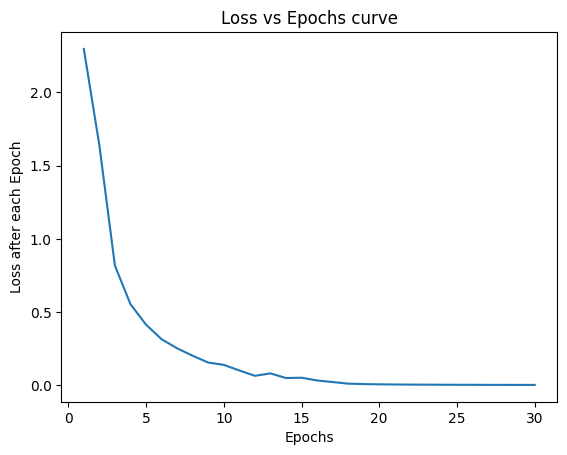

In [92]:
def loss_plotter(epoch_arr,losses):
    plt.title("Loss vs Epochs curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss after each Epoch")
    plt.plot(epoch_arr,losses)
loss_plotter(epoch_arr,losses)

This ipynb file belongs to Mukesh Chowdary Vinjam

In [77]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784',version=1)
X=np.array(mnist.data)
y=np.array(mnist.target)

object
int64
(70000, 784) (70000,)


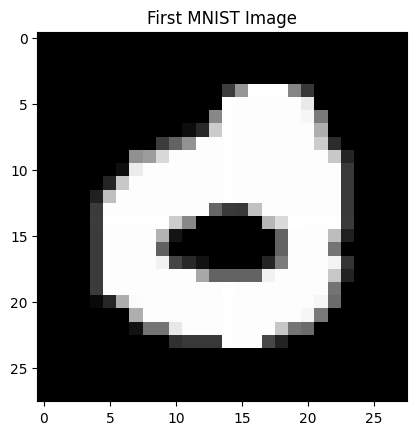

In [78]:
print(y.dtype)
y=y.astype(int)
print(y.dtype)
print(X.shape,y.shape)

X=X/255.0

plt.imshow(X[1999].reshape(28,28), cmap='gray')
plt.title("First MNIST Image")
plt.show()

In [79]:
X_train=X[:2000]
y_train=y[:2000]
X_test=X[2000:2999]
y_test=y[2000:2999]
X_train[0].shape


(784,)

In [80]:
def one_hot(label):
    arr=np.zeros(10)
    arr[label]=1
    return arr
def one_hot_to_normal(arr):
    for i in range(len(arr)):
        if arr[i]==1:
            return i
def prob_to_result(arr):
    k=max(arr)
    for i in range(len(arr)):
        if arr[i]==max(arr):
            return i
y_train=np.array([one_hot(i) for i in y_train])
y_test=np.array([one_hot(i) for i in y_test])

In [93]:
#performance of neural network on unseen data
correct=0
for i in range(len(X_test)):
    global_results_arr=forward_propagator(hidden_layers+2,X_test[i],global_weights_arr,global_bias_arr)
    true=one_hot_to_normal(y_test[i])
    predicted=prob_to_result(global_results_arr[-1])
    if true==predicted:
        correct+=1
print((correct/len(X_test))*100)
print("Total Wrong predictions:",len(X_test)-correct)

91.09109109109109
Total Wrong predictions: 89


In [94]:
#training dataset accuracy
correct=0
for i in range(len(X_train)):
    global_results_arr=forward_propagator(hidden_layers+2,X_train[i],global_weights_arr,global_bias_arr)
    true=one_hot_to_normal(y_train[i])
    predicted=prob_to_result(global_results_arr[-1])
    if true==predicted:
        correct+=1
print((correct/len(X_train))*100)
print("Total Wrong predictions:",len(X_train)-correct)

100.0
Total Wrong predictions: 0


#### As you can see above, the training data when passed through the neural net (training data validation) achieved 100% accuracy this is mainly due to:
##### ->The Neural Network has approximately about 26k parameters  
[(784 input_nodes*32 hidden_nodes(1st hidden layer) + 32 bias) + (32 hidden_layer 1 nodes*32 hidden_layer2_nodes + 32 h2 bias) + (32 hidden_layer2 nodes * 10 output_nodes + 10 output_bias)] ~= 26k params
##### -> but from the MNIST dataset we are using only 2000 training images out of 60k images, so that the model remembers the exact patterns that it learned during training we often call this as "OVERFITTING". Decreasing the number of hidden nodes can help the Neural nets with overcoming the overfitting phenomenon 
##### -> but please note that the neural Net has generalized more on the unseen data (1000 images) thus achieving "91.09109109109109%" accuracy (for now i really wanto to stay away from the confusion matrix) so there's no need of decreasing the hidden nodes for now, but what we can do is training the neural net on more data (talk about 20k - 30k images), this may fix the 100% accuracy thing on the training data validation